# Death Quanta - Bootstrapping

In [ ]:
import os
import sys
import shutil
import math
import warnings
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import *
from enum import Enum
from scipy.spatial import Voronoi
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import LabelEncoder
from scipy.stats import wasserstein_distance
sys.path.append("/home/esraan/CellDeathSpreading/")
from src.utils import get_experiment_cell_death_times_by_specific_siliding_window,read_experiment_cell_xy_and_death_times
from src.NucleationAndPropagationMeasurements import replace_ugly_long_name
from src.quanta_utils import get_neighbors
from src.DeathQuantaGlobal import DeathQuantaGlobal

In [ ]:
exps_dir_name = "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/"
meta_data_file_full_path= "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/all_csv_files_minutes_microns_with_sytox.csv"
meta_data_extract_exp_names= pd.read_csv(meta_data_file_full_path)
exp_names = meta_data_extract_exp_names.iloc[:,1]
group_data = {}
for idx in range(len(exp_names)):
    # if not all(meta_data_extract_exp_names[meta_data_extract_exp_names['File Name'] == exp_names[idx]]["DeathMode"] == 'Apoptosis'):
    #     continue
    if 'nec' in exp_names[idx] or 'apop' in exp_names[idx] or 'out' in exp_names[idx] or 'skt' in exp_names[idx].lower() or 'puredeath3' in exp_names[idx] or 'field3' in exp_names[idx]:# or 'zvad_fullmedia_puredeath3_sytox_based' in exp_names[idx]:
        continue
    
    # if 'pure' not in exp_names[idx]:# or 'zvad_fullmedia_puredeath3_sytox_based' in exp_names[idx]:
    #     continue
    print(exp_names[idx])
    exp_full_path = os.path.join(exps_dir_name, exp_names[idx])
    csv_file = pd.read_csv(exp_full_path)
    dist_threshold = 100 # microns
    cells_location = csv_file[["cell_x","cell_y"]].values
    di_times = csv_file[['death_time']].values
    death_modes = csv_file[["Mode"]].values if "Mode" in csv_file.columns else None
    de_qu = DeathQuantaGlobal(cells_xy=cells_location,
                        death_times=di_times, 
                        death_modes=death_modes,
                        dist_threshold=dist_threshold,
                        normalize = True,
                        n_type = 'z_score',
                        filter_neighbors_by_distance=True,
                        neighbors_level=1,
                        pure_type = "necrosis" if "nec" in exp_names[idx] else "apoptosis")
    
    tod_pairs_1 = de_qu.get_org_deltaTOD_neighbors_pairs()
    de_qu.calc_permuted_deltaTOD_neighbors_pairs(uniform_deltaTOD=False)
    print(de_qu.calc_p_val())
    print([(mode, np.mean(np.array(tod_pairs_1.get(mode, [])))) for mode in de_qu.le.classes_])
    # group_data[meta_data_extract_exp_names[meta_data_extract_exp_names['File Name'] == exp_names[idx]]["Origin"].values[0]] = tod_pairs_1 
    break 
# tod_pairs_1.get('apoptosis', []) + tod_pairs_1.get('necrosis', []) if isinstance(tod_pairs_1, dict) else tod_pairs_1

In [5]:
exps_dir_name = "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/"
meta_data_file_full_path= "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/all_csv_files_minutes_microns_with_sytox.csv"
meta_data_extract_exp_names= pd.read_csv(meta_data_file_full_path)
exp_names = meta_data_extract_exp_names.iloc[:,1]
group_data = {}
for idx in range(0, len(exp_names)):
    # if not all(meta_data_extract_exp_names[meta_data_extract_exp_names['File Name'] == exp_names[idx]]["DeathMode"] == 'Apoptosis'):
    #     continue
    # if 'mix' in exp_names[idx] or 'outlier' in exp_names[idx] or 'skt' in exp_names[idx].lower() or 'puredeath3' in exp_names[idx] or 'field3' in exp_names[idx]:# or 'zvad_fullmedia_puredeath3_sytox_based' in exp_names[idx]:
    #     continue
    if 'pure' not in exp_names[idx]:# or 'zvad_fullmedia_puredeath3_sytox_based' in exp_names[idx]:
        continue
    # if 'ROI#10_annotation_nec' not in exp_names[idx]:
    #     continue
    print(exp_names[idx], idx)
    exp_full_path = os.path.join(exps_dir_name, exp_names[idx])
    csv_file = pd.read_csv(exp_full_path)
    dist_threshold = 100 # microns
    cells_location = csv_file[["cell_x","cell_y"]].values
    di_times = csv_file[['death_time']].values
    death_modes = csv_file[["Mode"]].values if "Mode" in csv_file.columns else None
    de_qu = DeathQuantaGlobal(cells_xy=cells_location,
                        death_times=di_times, 
                        death_modes=death_modes,
                        dist_threshold=dist_threshold,
                        normalize = True,
                        n_type = 'z_score',
                        filter_neighbors_by_distance=True,
                        neighbors_level=1,
                        n_permutation=100,
                        pure_type = "necrosis" if "nec" in exp_names[idx] or 'pure' in exp_names[idx] else "apoptosis")
    
    tod_pairs_1 = de_qu.get_org_deltaTOD_neighbors_pairs()
    de_qu.calc_permuted_deltaTOD_neighbors_pairs(uniform_deltaTOD=True)
    # print(de_qu.calc_p_val())
    # print([(mode, np.mean(np.array(tod_pairs_1))) for mode in de_qu.le.classes_])
    if group_data.get(meta_data_extract_exp_names[meta_data_extract_exp_names['File Name'] == exp_names[idx]]["Origin"].values[0]):
        temp = group_data[meta_data_extract_exp_names[meta_data_extract_exp_names['File Name'] == exp_names[idx]]["Origin"].values[0]]
    else:
        temp = {'necrosis': [], 'apoptosis': []}
    temp.get('necrosis' if 'nec' in exp_names[idx] else 'apoptosis', []).extend(de_qu.calc_p_val())
    group_data[meta_data_extract_exp_names[meta_data_extract_exp_names['File Name'] == exp_names[idx]]["Origin"].values[0]] = temp
    # break 
# tod_pairs_1.get('apoptosis', []) + tod_pairs_1.get('necrosis', []) if isinstance(tod_pairs_1, dict) else tod_pairs_1  

purecolony3_sytox_based.csv 15


/home/esraan/CellDeathSpreading/src/DeathQuantaGlobal.py:103: UserWarning: No indices found below the threshold. Returning None for p-value and deltaTOD pairs.
  warnings.warn("No indices found below the threshold. Returning None for p-value and deltaTOD pairs.")


purecolony_sytox_based.csv 16


/home/esraan/CellDeathSpreading/src/DeathQuantaGlobal.py:103: UserWarning: No indices found below the threshold. Returning None for p-value and deltaTOD pairs.
  warnings.warn("No indices found below the threshold. Returning None for p-value and deltaTOD pairs.")


purecolony2_sytox_based.csv 17


...

3-11-23_10ah2bmch_ml+zvad_fullmedia_puredeath1_sytox_based.csv 26


/home/esraan/CellDeathSpreading/src/DeathQuantaGlobal.py:103: UserWarning: No indices found below the threshold. Returning None for p-value and deltaTOD pairs.
  warnings.warn("No indices found below the threshold. Returning None for p-value and deltaTOD pairs.")


3-11-23_10ah2bmch_ml+zvad_fullmedia_puredeath2_sytox_based.csv 27


/home/esraan/CellDeathSpreading/src/DeathQuantaGlobal.py:103: UserWarning: No indices found below the threshold. Returning None for p-value and deltaTOD pairs.
  warnings.warn("No indices found below the threshold. Returning None for p-value and deltaTOD pairs.")


3-11-23_10ah2bmch_ml+zvad_fullmedia_puredeath3_sytox_based.csv 28


In [ ]:
len(exp_names)

In [4]:
import csv

# Save the dictionary in long format to a CSV file
with open("group_data_long_format_pure.csv", "w", newline="") as csv_file:
    writer = csv.writer(csv_file)
    writer.writerow(["Origin", "Type", "Metric", "Value"])  # Header
    for origin, types in group_data.items():
        for type_, values in types.items():
            metrics = ["pvalue", "expected", "observed"]
            for metric, value in zip(metrics, values):
                writer.writerow([origin, type_, metric, value])

# Extra

In [13]:
len(formatted_files)

978

In [20]:
import pandas as pd
import re

# Define the directory path
path_dir = "/sise/assafzar-group/assafzar/Esraa/PureSingleCellCroppedAnnotated/SytoxSingleCellCropped/"

# Extract TrackID and death_time from filenames
data = []
for file_name in os.listdir(path_dir):
    try:
        track_id_match = re.search(r"ome_#(\d+)_", file_name)
        death_time_match = re.search(r"_tod-(\d+\.?\d*).", file_name)
        if track_id_match and death_time_match:
            track_id = int(track_id_match.group(1))
            death_time = float(death_time_match.group(1))
            data.append({"TrackID": track_id, "death_time": death_time, "file_name": file_name})
        else:
            print(f"Could not parse file name: {file_name}")
    except ValueError:
        print(f"Could not parse file name: {file_name}")

# Create a DataFrame
df = pd.DataFrame(data)

# # Display the DataFrame
# # Create separate DataFrames based on file_name patterns
df_purecolony = df[df['file_name'].str.contains('purecolony_')]
df_purecolony2 = df[df['file_name'].str.contains('purecolony2_')]
df_purecolony3 = df[df['file_name'].str.contains('purecolony3_')]

# Display the DataFrames
print("Purecolony DataFrame:")
print(df_purecolony)

print("\nPurecolony2 DataFrame:")
print(df_purecolony2)

print("\nPurecolony3 DataFrame:")
print(df_purecolony3)

Purecolony DataFrame:
     TrackID  death_time                                      file_name
0        704        38.0   purecolony_10x GFP.ome_#704_sytox_tod-38.tif
1        683        36.0   purecolony_10x GFP.ome_#683_sytox_tod-36.tif
2        744        42.0   purecolony_10x GFP.ome_#744_sytox_tod-42.tif
3       1121        38.0  purecolony_10x GFP.ome_#1121_sytox_tod-38.tif
4        719        43.0   purecolony_10x GFP.ome_#719_sytox_tod-43.tif
..       ...         ...                                            ...
973      977        50.0   purecolony_10x GFP.ome_#977_sytox_tod-50.tif
974      945        52.0   purecolony_10x GFP.ome_#945_sytox_tod-52.tif
975      949        62.0   purecolony_10x GFP.ome_#949_sytox_tod-62.tif
976      565        52.0   purecolony_10x GFP.ome_#565_sytox_tod-52.tif
977      600        55.0   purecolony_10x GFP.ome_#600_sytox_tod-55.tif

[978 rows x 3 columns]

Purecolony2 DataFrame:
      TrackID  death_time                                        f

In [21]:
df_purecolony.to_csv("df_purecolony.csv", index=False)
df_purecolony2.to_csv("df_purecolony2.csv", index=False)
df_purecolony3.to_csv("df_purecolony3.csv", index=False)

In [34]:
import pandas as pd
import os
import numpy as np

# Define directories
dir_1 = "/sise/assafzar-group/assafzar/Esraa/PureSingleCellCroppedAnnotated/track_tod_sytox"
dir_2 = "/sise/assafzar-group/assafzar/Esraa/PureSingleCellCroppedAnnotated/tracks/"

# List all CSV files in dir_1
files_dir_1 = [f for f in os.listdir(dir_1) if f.endswith('.csv')]

# Iterate through each file in dir_1
for file_name in files_dir_1:
    # Construct the counterpart file path in dir_2
    file_path_1 = os.path.join(dir_1, file_name)
    file_path_2 = os.path.join(dir_2, file_name)

    # Check if the counterpart file exists in dir_2
    if os.path.exists(file_path_2):
        # Read the CSV files
        df_1 = pd.read_csv(file_path_1)
        df_2 = pd.read_csv(file_path_2)

        # Check the difference for each TrackID
        comparison = df_1.apply(lambda row: (row['TrackID'], row['death_time'] - df_2.loc[df_2['TrackID'] == row['TrackID'], 'death_frame'].values[0]) 
                if row['TrackID'] in df_2['TrackID'].values else (row['TrackID'], None), axis=1)

        # Print the comparison results
        print(f"Comparison for file: {file_name}")
        print(comparison)
        break
    else:
        print(f"Counterpart file not found for: {file_name}")

/tmp/ipykernel_3223932/3239710819.py:22: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2 = pd.read_csv(file_path_2)


Comparison for file: purecolony.csv
0        (704, 1.0)
1       (683, -1.0)
2        (744, 5.0)
3      (1121, -1.0)
4        (719, 1.0)
           ...     
973      (977, 3.0)
974      (945, 1.0)
975      (949, 2.0)
976      (565, 3.0)
977      (600, 3.0)
Length: 978, dtype: object


In [40]:
comparison_df = comparison.apply(pd.Series)
comparison_df.columns = ['TrackID', 'Difference']
filtered_comparison_df = comparison_df[comparison_df['Difference'] <= 5]
filtered_comparison_df

,TrackID,Difference
0,704.0,1.0
1,683.0,-1.0
2,744.0,5.0
3,1121.0,-1.0
4,719.0,1.0
...,...,...
973,977.0,3.0
974,945.0,1.0
975,949.0,2.0
976,565.0,3.0


In [41]:
mean_difference = filtered_comparison_df['Difference'].mean()
print(mean_difference)

2.076045627376426


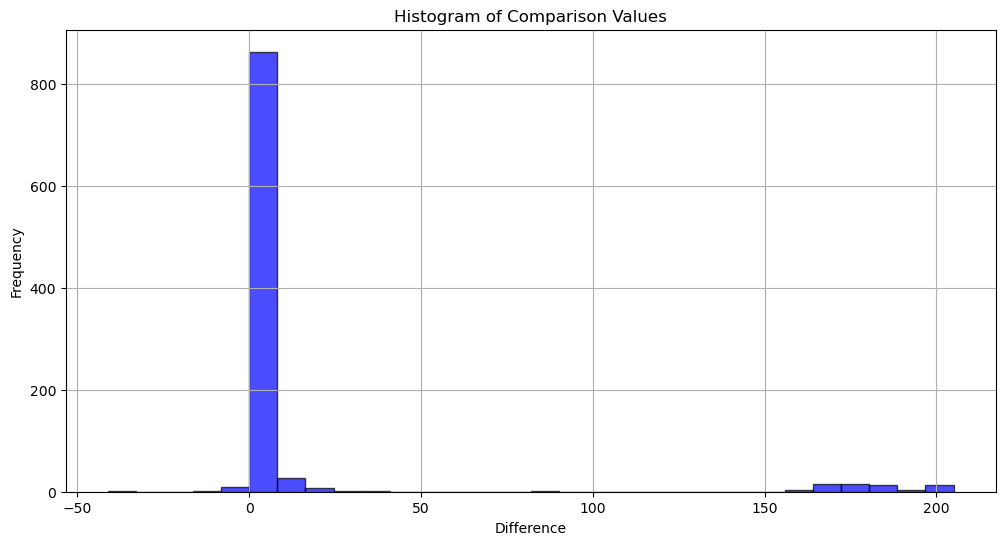

In [33]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.hist(comparison.values, bins=30, color='blue', alpha=0.7, edgecolor='black')
plt.title("Histogram of Comparison Values")
plt.xlabel("Difference")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [3]:
import os
import sys
directory_path = "/sise/assafzar-group/assafzar/Esraa/PureSingleCellCroppedAnnotated/FullDICSingleCellCropped/"
files = os.listdir(directory_path)

# Format files for YAML
formatted_files = [f"- {os.path.join(directory_path, file)}" for file in files if 'purecolony2_' in file and file.endswith('.tif')]

# Write formatted files to a text file
with open("formatted_files_2.txt", "w") as file:
    file.write("\n".join(formatted_files))

# Print the number of formatted files
print(len(formatted_files))

1109
